<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/iLogos/nsst.jpg" width="400" height="100">

# DEMI | NOVA SST

## Mecânica dos Sólidos I

# II. Análise de extensões. Extensometria. Equações da compatibilidade.

## Problema 5 <a name="PII55"></a>

Um quadrado de largura unitária, desenhado numa chapa metálica deforma-se de acordo
com o seguinte campo de deslocamentos (Origem dos eixos no canto inferior esquerdo e unidades em mm):

\begin{equation*}
	\begin{aligned}
		u &= -0,002x - 0,003y  \\
		v &= 0,001x + 0,0025y \\
	\end{aligned}
\end{equation*}

[a)](#A) Determine o estado de deformação, no referencial dado, no ponto $P(1,1)$. O estado de deformação varia espacialmente
o plano da placa?

[b)](#B) Qual seria a leitura de uma roseta de extensómetros a 45 $^\circ$.

## Resolução

Visualização da deformada associado ao campo de deslocamentos enunciado:

Deslocamentos da placa, num determinado instante t:

ux = -0.002*X1 - 0.003*X2  [m]
uy = 0.001*X1 + 0.0025*X2  [m]


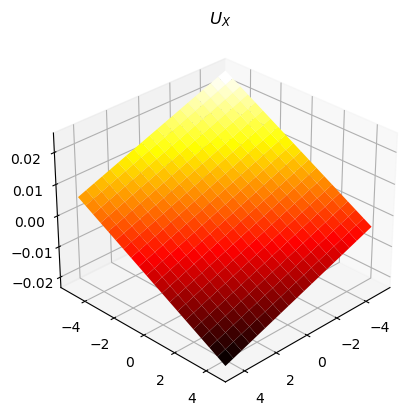

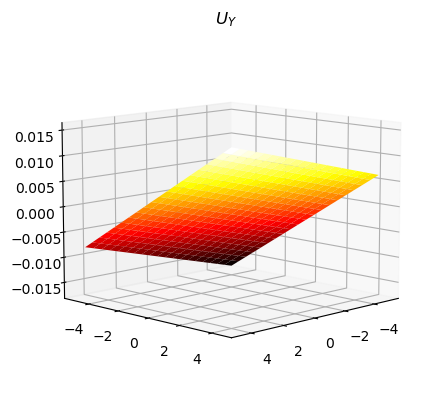

In [1]:
import numpy as np

from sympy import *
import matplotlib.pyplot as plt
from pylab import meshgrid,cm,imshow,contour,clabel,colorbar,axis,title,show

X1, X2 = symbols('X1 X2')

def Ux(X1,X2): return -0.002*X1 - 0.003*X2
def Uy(X1,X2): return 0.001*X1 + 0.0025*X2

print("Deslocamentos da placa, num determinado instante t:\n")
print("ux =",Ux(X1,X2),' [m]')
print("uy =",Uy(X1,X2),' [m]')

xa = np.arange(-5.0,5.0,.5)
ya = np.arange(-5.0,5.0,.5)
Xa,Ya = np.meshgrid(xa, ya) # grid of point

fig = plt.figure(121)
ax1 = fig.add_subplot(111, projection='3d')
cset = ax1.plot_surface(Xa,Ya, Ux(Xa,Ya), cmap=cm.hot)
ax1.clabel(cset, fontsize=9, inline=1)
title(r'$U_X$')
ax1.view_init(30, 45)
plt.show()

fig = plt.figure(121)
ax1 = fig.add_subplot(111, projection='3d')
cset = ax1.plot_surface(Xa,Ya, Uy(Xa,Ya), cmap=cm.hot)
ax1.clabel(cset, fontsize=9, inline=1)
title(r'$U_Y$')
ax1.view_init(10, 45)
plt.show()

#### a) Determine o estado de deformação, no referencial dado, no ponto $P(1,1)$. O estado de deformação varia espacialmente o plano da placa?<a name="A"></a>

([enunciatum](#PII55))

As componentes cartesianas do tensor das deformações infinitésimais são calculadas através da seguinte relação deslocamentos-deformação:

\begin{equation*}
\varepsilon_{ij} = \frac{1}{2}\left( \frac{\partial u_i}{\partial x_j}
+ \frac{\partial u_j}{\partial x_i} \right)
\end{equation*}

Em estado plano de deformação as componentes de deformação são:

\begin{equation*}
\begin{aligned}
\varepsilon_{xx} &= \frac{\partial u}{\partial x} \\
\varepsilon_{yy} &= \frac{\partial v}{\partial y} \\
\varepsilon_{xy} & \equiv \frac{\gamma_{xy}}{2} = \frac{1}{2}\left( \frac{\partial u}{\partial y} + \frac{\partial v}{\partial x} \right) \\
\end{aligned}
\end{equation*}

ou em forma tensorial no plano,

\begin{equation*}
\varepsilon_{ij} =
\begin{bmatrix}
\varepsilon_{xx} & \varepsilon_{xy}\\
\varepsilon_{xy} & \varepsilon_{yy}\\
\end{bmatrix}
\end{equation*}

In [2]:
u, v, x, y = symbols('u v x y')

A = -0.002
B = -0.003
C = 0.001
D = 0.0025

def u(x,y): return A*x + B*y
def v(x,y): return C*x + D*y

u1 = u(x,y); print('desloc. em x : u  = ',u1)
v1 = v(x,y); print('desloc. em y : v = ',v1)

# componentes cartesianas da matriz das deformações
exx = diff(u1, x)
print('\nexx = du\\dx :','{:.4f}'.format(exx))
eyy = diff(v1, y)
print('eyy = dv\\dy :','{:.4f}'.format(eyy))
exy  = 0.5*(diff(u1, y) + diff(v1, x) )
print('exy = 1\\2 gxy = 1\\2(du\\dy+dv\\dx) :','{:.4f}'.format(exy))

print('\nMatriz das deformações, [D] :\n')
def mD(exx,exy,eyy):
    return np.array([[exx,exy],[exy,eyy]])

mD0 = mD(exx,exy,eyy)
np.set_printoptions(precision=2,suppress=True)
print(mD0)

desloc. em x : u  =  -0.002*x - 0.003*y
desloc. em y : v =  0.001*x + 0.0025*y

exx = du\dx : -0.0020
eyy = dv\dy : 0.0025
exy = 1\2 gxy = 1\2(du\dy+dv\dx) : -0.0010

Matriz das deformações, [D] :

[[-0.00200000000000000 -0.00100000000000000]
 [-0.00100000000000000 0.00250000000000000]]


de onde resulta,

\begin{equation*}
\varepsilon_{ij} =
\begin{bmatrix}
-0.0020 & -0.0010\\
-0.0010 & 0.0025\\
\end{bmatrix}
\end{equation*}

De notar que o campo de deformação do quadrado de largura unitária é constante pelo que não varia com a coordenada de um ponto material no seu interior.

#### b) Qual seria a leitura de uma roseta de extensómetros a 45 $^\circ$. <a name="B"></a>

([enunciatum](#PII55))

A medição de um extensómetro orientado de um determinado ângulo $\theta^\circ$ em relação ao eixo horizontal vem expressa em função das componentes do tensor das deformações por:

\begin{equation*}
\varepsilon(\theta) = \varepsilon_{xx}\cos^2\theta + \varepsilon_{yy}\sin^2\theta + \gamma_{xy}\sin\theta\cos\theta
\end{equation*}

In [21]:
def extensometro(eXX,eYY,gXY,t): return eXX*np.cos(t)**2 +  eYY*np.sin(t)**2 +  gXY*np.sin(t)*np.cos(t)

angb = 45
eb = extensometro(exx,eyy,2*exy,np.deg2rad(angb))
print('Extensõmetro a 45 deg: ------------')
print('calc. 1 :: \n- eXXcos(t)^2 +  eYYsin(t)^2 + gXYsin(t)cos(t) :')
print(f'- extens. 45deg = {eb:.3e}')

eb2 = (exx+eyy)/2+ exy
print('calc. 2 ::\n- (exx+eyy)\\2 + exy :')
print(f'- extens. 45deg = {eb2:.3e}')

Extensõmetro a 45 deg: ------------
calc. 1 :: 
- eXXcos(t)^2 +  eYYsin(t)^2 + gXYsin(t)cos(t) :
- extens. 45deg = -7.500e-4
calc. 2 ::
- (exx+eyy)\2 + exy :
- extens. 45deg = -7.500e-4


- Para $\theta = 45^\circ$ ($\cos(45^\circ) = \sin(45^\circ) = \sqrt{2}/2$):

\begin{equation*}
\varepsilon_{+45^\circ} = \frac{1}{2}(\varepsilon_{xx} + \varepsilon_{yy} + \gamma_{xy}) =
\frac{\varepsilon_{xx} + \varepsilon_{yy}}{2} + \varepsilon_{xy} =  -7.50000e-4
\end{equation*}

- Para $\theta = 0^\circ$:

$\varepsilon_{0^\circ} \equiv \varepsilon_{xx} = -0.002$.

- Para $\theta = 90^\circ$:

$\varepsilon_{90^\circ} \equiv \varepsilon_{yy} = 0.0025$.


---

Copyright (c) [Mecânica dos Sólidos I - DEMI - NOVA-SST]

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>

